In [3]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
import joblib

In [4]:
# Load PCA-transformed features (USED for clustering)
X = pd.read_csv("data/pca_8_components.csv")

# Load labels (ONLY for evaluation)
y = pd.read_csv("data/labels.csv").squeeze()  # convert to Series

In [5]:
print(X.shape)
print(y.shape)

(639846, 8)
(639846,)


K-Means with Hyperparameter Tuning

In [5]:
X_sample = X.sample(n=100000, random_state=42)

In [5]:
results = []

for k in range(2, 11):
    for n_init in [10, 20, 50]:
        
        kmeans = KMeans(
            n_clusters=k,
            init='k-means++',
            n_init=n_init,
            max_iter=300,
            random_state=42
        )
        
        labels = kmeans.fit_predict(X_sample)
        sil = silhouette_score(X_sample, labels)
        
        results.append((k, n_init, sil))
        print(f"K={k}, n_init={n_init}, Silhouette={sil:.4f}")

K=2, n_init=10, Silhouette=0.4857
K=2, n_init=20, Silhouette=0.4857
K=2, n_init=50, Silhouette=0.4857
K=3, n_init=10, Silhouette=0.5022
K=3, n_init=20, Silhouette=0.5022
K=3, n_init=50, Silhouette=0.5022
K=4, n_init=10, Silhouette=0.5077
K=4, n_init=20, Silhouette=0.5077
K=4, n_init=50, Silhouette=0.5077
K=5, n_init=10, Silhouette=0.4063
K=5, n_init=20, Silhouette=0.5139
K=5, n_init=50, Silhouette=0.5139
K=6, n_init=10, Silhouette=0.4181
K=6, n_init=20, Silhouette=0.4181
K=6, n_init=50, Silhouette=0.4185
K=7, n_init=10, Silhouette=0.4228
K=7, n_init=20, Silhouette=0.4228
K=7, n_init=50, Silhouette=0.4228
K=8, n_init=10, Silhouette=0.4196
K=8, n_init=20, Silhouette=0.4196
K=8, n_init=50, Silhouette=0.4216
K=9, n_init=10, Silhouette=0.4201
K=9, n_init=20, Silhouette=0.4199
K=9, n_init=50, Silhouette=0.4199
K=10, n_init=10, Silhouette=0.4259
K=10, n_init=20, Silhouette=0.4259
K=10, n_init=50, Silhouette=0.4259


In [6]:
best_k = 5
best_n_init = 20

kmeans = KMeans(
    n_clusters=best_k,
    init='k-means++',
    n_init=best_n_init,
    max_iter=300,
    random_state=42
)

cluster_labels = kmeans.fit_predict(X)

In [7]:
joblib.dump(kmeans, "models/kmeans.pkl")

['models/kmeans.pkl']

Evaluation

In [7]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, adjusted_rand_score

# --- Internal Validation ---
silhouette_km = silhouette_score(X, cluster_labels)
dbi_km = davies_bouldin_score(X, cluster_labels)

# --- External Validation ---
ari_km = adjusted_rand_score(y, cluster_labels)

# --- Print Results ---
print("K-Means Evaluation Metrics")
print(f"Silhouette Score: {silhouette_km:.4f}")
print(f"Davies-Bouldin Index: {dbi_km:.4f}")
print(f"Adjusted Rand Index: {ari_km:.4f}")

K-Means Evaluation Metrics
Silhouette Score: 0.5144
Davies-Bouldin Index: 0.8482
Adjusted Rand Index: 0.1498


Visualization of Mapping

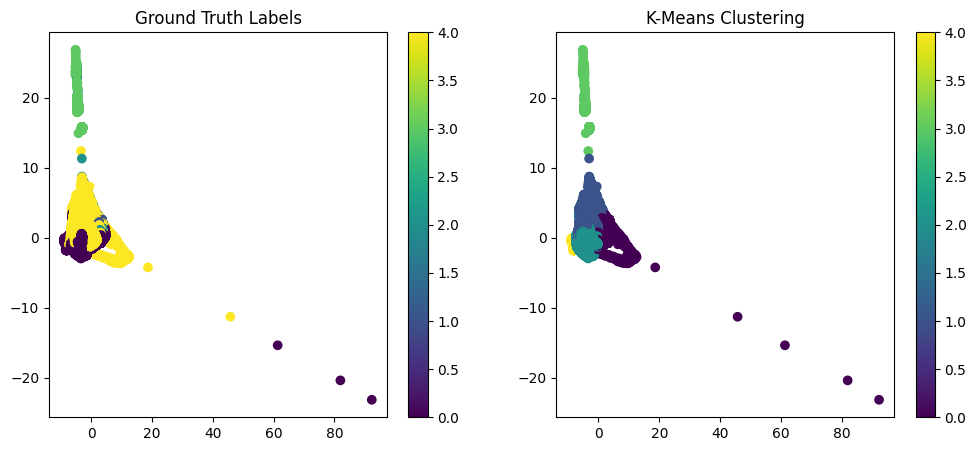

In [24]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Reduce to 2D for visualization
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Ground Truth ---
scatter1 = axes[0].scatter(X_2d[:, 0], X_2d[:, 1], c=y, cmap='viridis')
axes[0].set_title("Ground Truth Labels")
plt.colorbar(scatter1, ax=axes[0])

# --- Clustering Result ---
scatter2 = axes[1].scatter(X_2d[:, 0], X_2d[:, 1], c=cluster_labels, cmap='viridis')
axes[1].set_title("K-Means Clustering")
plt.colorbar(scatter2, ax=axes[1])

plt.show()

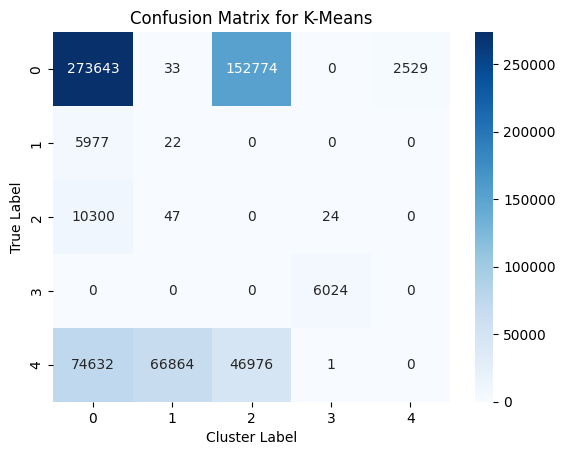

In [18]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y, cluster_labels)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Cluster Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix for K-Means")
plt.show()